In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import gzip

Load the data

In [4]:
# Load ER labels
labels = pd.read_csv("class.tsv", sep="\t", header=None)[0].values

# Load gene metadata
with open("/content/columns.tsv", "rt") as f:
    gene_lines = [line for line in f if not line.startswith("#")]
gene_map = pd.read_csv(StringIO("".join(gene_lines)), sep="\t")

# Load expression matrix
with open("/content/filtered.tsv", "rt") as f:
    expression = pd.read_csv(f, sep="\t")
expression.columns = expression.columns.astype(str).str.strip()

# Extract GATA3 and XBP1
XBP1_ID = 4404
GATA3_ID = gene_map.loc[gene_map["GeneSymbol"] == "GATA3", "ID"].values[0]

gata3 = expression[str(GATA3_ID)].values
xbp1  = expression[str(XBP1_ID)].values

print("GATA3 ID:", GATA3_ID)
print("XBP1 in expression columns:", str(XBP1_ID) in expression.columns)

GATA3 ID: 4359
XBP1 in expression columns: True


PCA function

In [5]:
ER_POS_COLOR = "#008B8B"
ER_NEG_COLOR = "#C71585"

def sample_colors(labels):
    return [ER_POS_COLOR if l == 1 else ER_NEG_COLOR for l in labels]

def perform_pca(X, labels=None, k=None):
    centered = X - np.mean(X, axis=0)
    cov = np.cov(centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    order = np.argsort(eigenvalues)[::-1]
    eigenvalues  = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    if labels is not None:
        pc1_proj = centered @ eigenvectors[:, 0]
        if np.mean(pc1_proj[labels == 1]) < np.mean(pc1_proj[labels == 0]):
            eigenvectors[:, 0] *= -1
        if eigenvectors.shape[1] >= 2:
            if np.cross(eigenvectors[:, 0], eigenvectors[:, 1]) < 0:
                eigenvectors[:, 1] *= -1

    if k is not None:
        eigenvectors = eigenvectors[:, :k]
        eigenvalues  = eigenvalues[:k]

    return eigenvectors, eigenvalues, centered

GATA3 vs XBP1 scatter


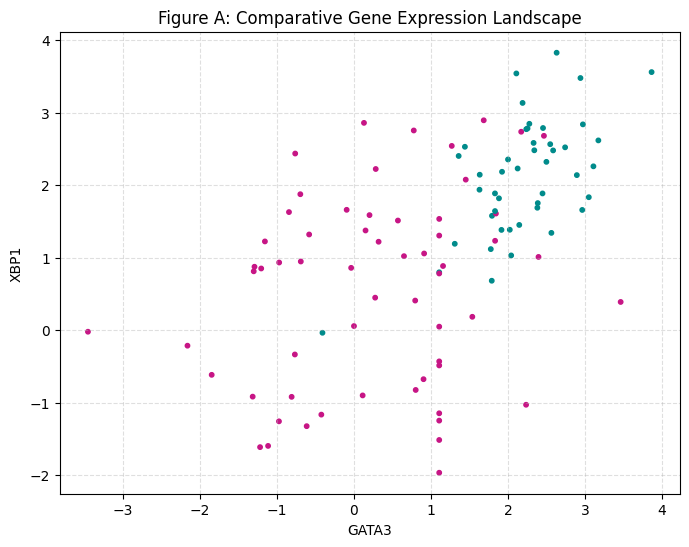

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(gata3, xbp1, c=sample_colors(labels), s=10)
plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Figure A: Comparative Gene Expression Landscape")
plt.grid(linestyle="--", alpha=0.4)
plt.savefig("figure_1a.png", dpi=150)
plt.show()

PC directions

/tmp/ipykernel_926/296552153.py:21: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  if np.cross(eigenvectors[:, 0], eigenvectors[:, 1]) < 0:


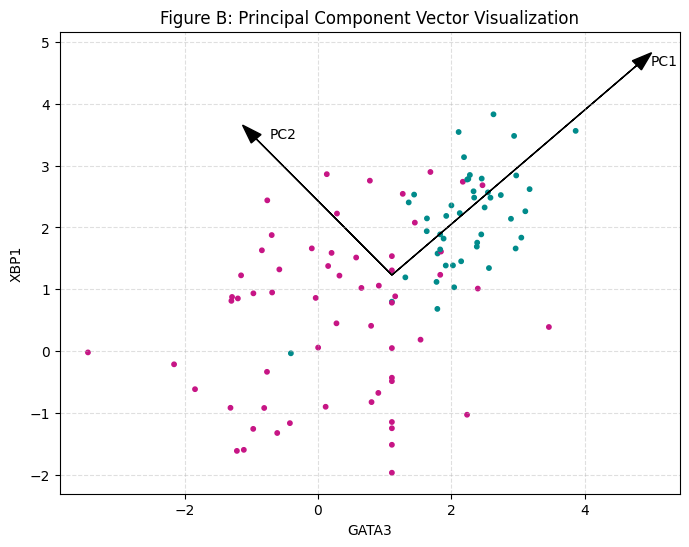

In [7]:
features = np.column_stack((gata3, xbp1))
eigenvectors, eigenvalues, centered = perform_pca(features, labels=labels)

pc1, pc2 = eigenvectors[:, 0], eigenvectors[:, 1]
proj_pc1 = centered @ pc1
proj_pc2 = centered @ pc2

mean_gata3, mean_xbp1 = np.mean(gata3), np.mean(xbp1)

plt.figure(figsize=(8, 6))
plt.scatter(gata3, xbp1, c=sample_colors(labels), s=10)
plt.arrow(mean_gata3, mean_xbp1, pc1[0]*5, pc1[1]*5,
          head_width=0.2, head_length=0.3, fc="black", ec="black")
plt.arrow(mean_gata3, mean_xbp1, pc2[0]*3, pc2[1]*3,
          head_width=0.2, head_length=0.3, fc="black", ec="black")
plt.text(mean_gata3 + pc1[0]*5 + 0.2, mean_xbp1 + pc1[1]*5, "PC1")
plt.text(mean_gata3 + pc2[0]*3 + 0.2, mean_xbp1 + pc2[1]*3, "PC2")
plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Figure B: Principal Component Vector Visualization")
plt.grid(linestyle="--", alpha=0.4)
plt.savefig("figure_1b.png", dpi=150)
plt.show()

Projection onto PC1

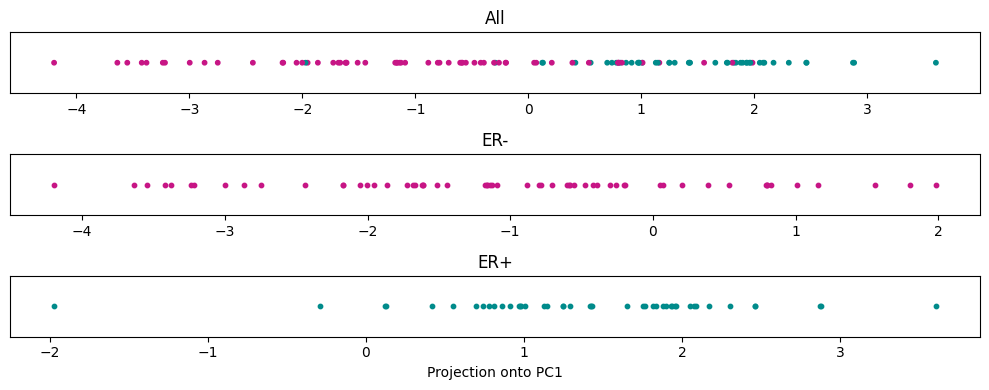

Variance explained by PC1: 0.7792
Variance explained by PC2: 0.2208


In [8]:
er_pos_pc1 = proj_pc1[labels == 1]
er_neg_pc1 = proj_pc1[labels == 0]

plt.figure(figsize=(10, 4))

plt.subplot(3, 1, 1)
plt.scatter(proj_pc1, np.zeros_like(proj_pc1), c=sample_colors(labels), s=10)
plt.yticks([])
plt.title("All")

plt.subplot(3, 1, 2)
plt.scatter(er_neg_pc1, np.zeros_like(er_neg_pc1), color=ER_NEG_COLOR, s=10)
plt.yticks([])
plt.title("ER-")

plt.subplot(3, 1, 3)
plt.scatter(er_pos_pc1, np.zeros_like(er_pos_pc1), color=ER_POS_COLOR, s=10)
plt.yticks([])
plt.title("ER+")
plt.xlabel("Projection onto PC1")

plt.tight_layout()
plt.savefig("figure_1c.png", dpi=150)
plt.show()

total_var = eigenvalues.sum()
print(f"Variance explained by PC1: {eigenvalues[0] / total_var:.4f}")
print(f"Variance explained by PC2: {eigenvalues[1] / total_var:.4f}")